In [3]:
import zipfile
import wfdb
import matplotlib.pyplot as plt
import os
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
extract_dir = Path("data/mit-bih-arrhythmia-database-1.0.0")

if not extract_dir.exists():
    with zipfile.ZipFile("data/mit-bih-arrhythmia-database-1.0.0.zip") as f:
        f.extractall("data")

In [6]:
record = wfdb.rdrecord("C:\\Machine_learning\\PRO\\data\\mit-bih-arrhythmia-database-1.0.0\\data_samples\\100")

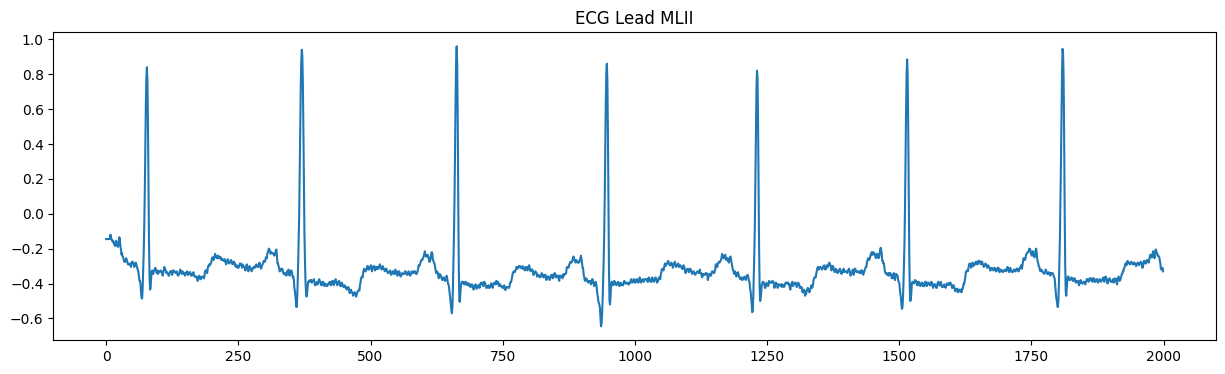

In [7]:
signal = record.p_signal[:,0]

plt.figure(figsize=(15,4))
plt.plot(signal[:2000])
plt.title("ECG Lead MLII")
plt.show()

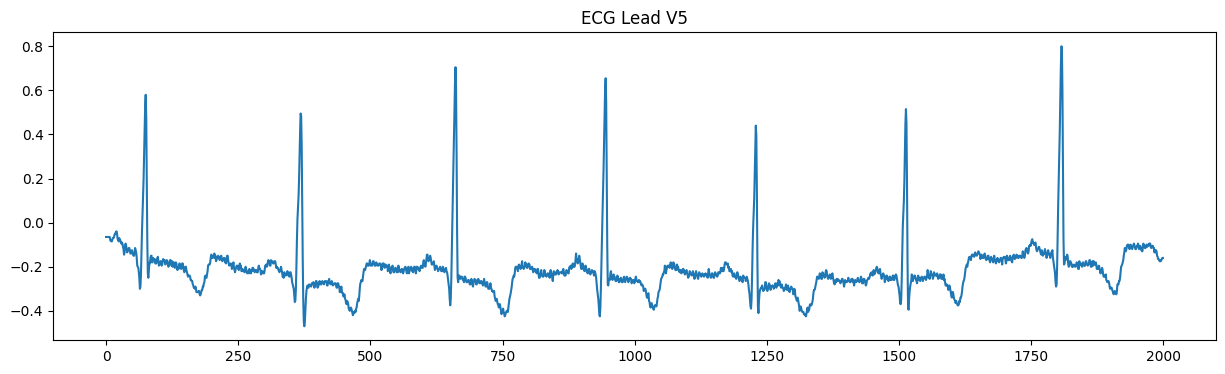

In [8]:
signal = record.p_signal[:,1]

plt.figure(figsize=(15,4))
plt.plot(signal[:2000])
plt.title("ECG Lead V5")
plt.show()

In [420]:
path = "C:\\Machine_learning\\PRO\\data\\mit-bih-arrhythmia-database-1.0.0\\data_samples"

In [421]:
records = []

for file in os.listdir(path):
    if(file.endswith(".hea")):
        records.append(file.removesuffix(".hea"))

len(records)

48

In [422]:
train_records, test_records = train_test_split(records, test_size=0.2, random_state=42)
print(f"train records size : {len(train_records)}")
print(f"test records size : {len(test_records)}")

train records size : 38
test records size : 10


In [423]:
def data_gen(records):

    X = []
    y = []

    window = 250
    half = window // 2

    for rec in records:

        record = wfdb.rdrecord(path + "\\" + rec)
        ann = wfdb.rdann(path + "\\" + rec, "atr")

        sig = record.p_signal[:, 0]

        for peak, label in zip(ann.sample, ann.symbol):

            if peak - half < 0:
                continue

            if peak + half >= len(sig):
                continue

            beat = sig[peak-half : peak+half]

            X.append(beat)
            y.append(label)

    return np.array(X), np.array(y)

In [424]:
X_train, y_train = data_gen(train_records)
X_test, y_test = data_gen(test_records)

In [425]:
print(Counter(y_train))

Counter({np.str_('N'): 56029, np.str_('L'): 8071, np.str_('R'): 7256, np.str_('V'): 6329, np.str_('/'): 5647, np.str_('A'): 2261, np.str_('F'): 786, np.str_('+'): 744, np.str_('~'): 486, np.str_('!'): 472, np.str_('"'): 433, np.str_('f'): 316, np.str_('E'): 106, np.str_('|'): 102, np.str_('J'): 81, np.str_('a'): 26, np.str_('x'): 23, np.str_('e'): 16, np.str_('Q'): 11, np.str_('j'): 7, np.str_('['): 6, np.str_(']'): 6, np.str_('S'): 2})


In [426]:
aami_map = {
    'N': 'N',
    'L': 'N',
    'R': 'N',
    'e': 'N',
    'j': 'N',

    'A': 'S',
    'a': 'S',
    'J': 'S',
    'S': 'S',

    'V': 'V',
    'E': 'V',

    'F': 'F',

    '/': 'Q',
    'f': 'Q',
    'Q': 'Q'
}


In [427]:
# mapped to AAMI EC57 classes:
def convert_to_aami(X, y):
    
    mask = np.array([label in aami_map for label in y])
    X = X[mask]
    y = np.array([aami_map[label] for label in y[mask]])
    
    return X, y

In [428]:
X_train, y_train = convert_to_aami(X_train, y_train)
X_test, y_test = convert_to_aami(X_test, y_test)

In [429]:
print(Counter(y_train))
print(Counter(y_test))

Counter({np.str_('N'): 71379, np.str_('V'): 6435, np.str_('Q'): 5974, np.str_('S'): 2370, np.str_('F'): 786})
Counter({np.str_('N'): 19214, np.str_('Q'): 2066, np.str_('V'): 800, np.str_('S'): 411, np.str_('F'): 16})


In [430]:
# label to index for model
label2idx = {
    'N': 0,
    'S': 1,
    'V': 2,
    'F': 3,
    'Q': 4
}

y_train = np.array([label2idx[x] for x in y_train])
y_test  = np.array([label2idx[x] for x in y_test])

In [431]:
# MIT-BIH annotations were mapped to AAMI EC57 classes:
# N, S, V, F, Q
#   
# After patient-level splitting, the F (Fusion Beat) class contained
# only 786 training samples and 16 test samples. Due to insufficient samples
# the final model was trained on the remaining four classes: N, S, V and Q.

mask_train = y_train != 3
mask_test = y_test != 3

X_train = X_train[mask_train]
y_train = y_train[mask_train]

X_test = X_test[mask_test]
y_test = y_test[mask_test]

y_train[y_train == 4] = 3
y_test[y_test == 4] = 3

In [432]:
print(np.unique(y_train))
print(np.unique(y_test))

[0 1 2 3]
[0 1 2 3]


In [433]:
# normalizing the dataset
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [434]:
X_train = X_train.reshape(-1, 250, 1)
X_test = X_test.reshape(-1, 250, 1)

In [435]:
print(X_train.shape)
print(y_train.shape)

print(np.unique(y_train))

(86158, 250, 1)
(86158,)
[0 1 2 3]


In [436]:
print(Counter(y_train))
print(Counter(y_test))

Counter({np.int64(0): 71379, np.int64(2): 6435, np.int64(3): 5974, np.int64(1): 2370})
Counter({np.int64(0): 19214, np.int64(3): 2066, np.int64(2): 800, np.int64(1): 411})


In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)

# class_freq = torch.bincount(y_train)
# class_weights = 1.0/class_freq.float()
# sample_weights = class_weights[y_train].double()

# sampler = WeightedRandomSampler(
#     weights=sample_weights,
#     num_samples=len(sample_weights),
#     replacement=True
# )

# train_loader = DataLoader(
#     train_ds,
#     batch_size=128,
#     sampler=sampler
# )

train_loader = DataLoader(
    train_ds,
    batch_size=128,
    shuffle=True
)

test_loader = DataLoader(
    test_ds,
    batch_size=128,
    shuffle=False
)

In [438]:
import torch
import torch.nn as nn

class ECG_CNN_LSTM(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(
            in_channels=1,
            out_channels=32,
            kernel_size=5,
            padding=2
        )

        self.conv2 = nn.Conv1d(
            in_channels=32,
            out_channels=64,
            kernel_size=5,
            padding=2
        )

        self.relu = nn.ReLU()

        self.pool = nn.MaxPool1d(2)

        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            dropout=0.3
        )

        self.fc = nn.Linear(128, 4)

    def forward(self, x):

        # x: (batch,250,1)

        x = x.permute(0, 2, 1)

        # (batch,1,250)

        x = self.pool(
                self.relu(
                    self.conv1(x)
                )
            )

        # (batch,32,125)

        x = self.pool(
                self.relu(
                    self.conv2(x)
                )
            )

        # (batch,64,62)

        x = x.permute(0, 2, 1)

        # (batch,62,64)

        output, (hidden, cell) = self.lstm(x)

        x = hidden[-1]

        x = self.fc(x)

        return x

In [439]:
from sklearn.utils.class_weight import compute_class_weight

weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train.numpy()),
    y=y_train.numpy()
)

weights = torch.tensor(weights, dtype=torch.float32, device=device)

criterion = nn.CrossEntropyLoss(weight=weights)
# criterion = nn.CrossEntropyLoss()

In [440]:
model = ECG_CNN_LSTM().to(device=device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [441]:
epochs = 20

for epoch in range(epochs):

    # --------------------
    # TRAINING
    # --------------------

    model.train()

    running_loss = 0
    train_correct = 0
    train_total = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        preds = outputs.argmax(dim=1)

        train_correct += (preds == y_batch).sum().item()

        train_total += y_batch.size(0)

    train_acc = train_correct / train_total

    # --------------------
    # VALIDATION
    # --------------------

    model.eval()

    test_correct = 0
    test_total = 0

    with torch.no_grad():

        for X_batch, y_batch in test_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            preds = outputs.argmax(dim=1)

            test_correct += (preds == y_batch).sum().item()

            test_total += y_batch.size(0)

    test_acc = test_correct / test_total

    # --------------------
    # PRINT
    # --------------------

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Loss: {running_loss/len(train_loader):.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Test Acc: {test_acc:.4f}"
    )

Epoch 1/20 | Loss: 0.2548 | Train Acc: 0.6901 | Test Acc: 0.0582
Epoch 2/20 | Loss: 0.1158 | Train Acc: 0.7502 | Test Acc: 0.1137
Epoch 3/20 | Loss: 0.0894 | Train Acc: 0.8030 | Test Acc: 0.2191
Epoch 4/20 | Loss: 0.0621 | Train Acc: 0.8622 | Test Acc: 0.2995
Epoch 5/20 | Loss: 0.0554 | Train Acc: 0.8879 | Test Acc: 0.2762
Epoch 6/20 | Loss: 0.0524 | Train Acc: 0.8903 | Test Acc: 0.4679
Epoch 7/20 | Loss: 0.0405 | Train Acc: 0.9188 | Test Acc: 0.3842
Epoch 8/20 | Loss: 0.0378 | Train Acc: 0.9251 | Test Acc: 0.4452
Epoch 9/20 | Loss: 0.0299 | Train Acc: 0.9406 | Test Acc: 0.3473
Epoch 10/20 | Loss: 0.0265 | Train Acc: 0.9472 | Test Acc: 0.4850
Epoch 11/20 | Loss: 0.0259 | Train Acc: 0.9505 | Test Acc: 0.4619
Epoch 12/20 | Loss: 0.0200 | Train Acc: 0.9565 | Test Acc: 0.3780
Epoch 13/20 | Loss: 0.0182 | Train Acc: 0.9611 | Test Acc: 0.5078
Epoch 14/20 | Loss: 0.0177 | Train Acc: 0.9662 | Test Acc: 0.5610
Epoch 15/20 | Loss: 0.0175 | Train Acc: 0.9638 | Test Acc: 0.4233
Epoch 16/20 | Loss:

In [442]:
from sklearn.metrics import classification_report

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())

print(classification_report(all_labels, all_preds))

              precision    recall  f1-score   support

           0       0.95      0.58      0.72     19214
           1       0.05      0.55      0.09       411
           2       0.25      0.91      0.39       800
           3       0.43      0.63      0.51      2066

    accuracy                           0.60     22491
   macro avg       0.42      0.67      0.43     22491
weighted avg       0.86      0.60      0.68     22491



In [262]:
torch.cuda.is_available()

True

In [263]:
device

device(type='cuda')